In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import plotly.express as px

In [3]:
# Cargar el archivo CSV
data = pd.read_csv('data/train.csv')

In [4]:
# inspecion inicial
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# valores nulos
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
# valores duplicados
print(data.duplicated().sum())

0


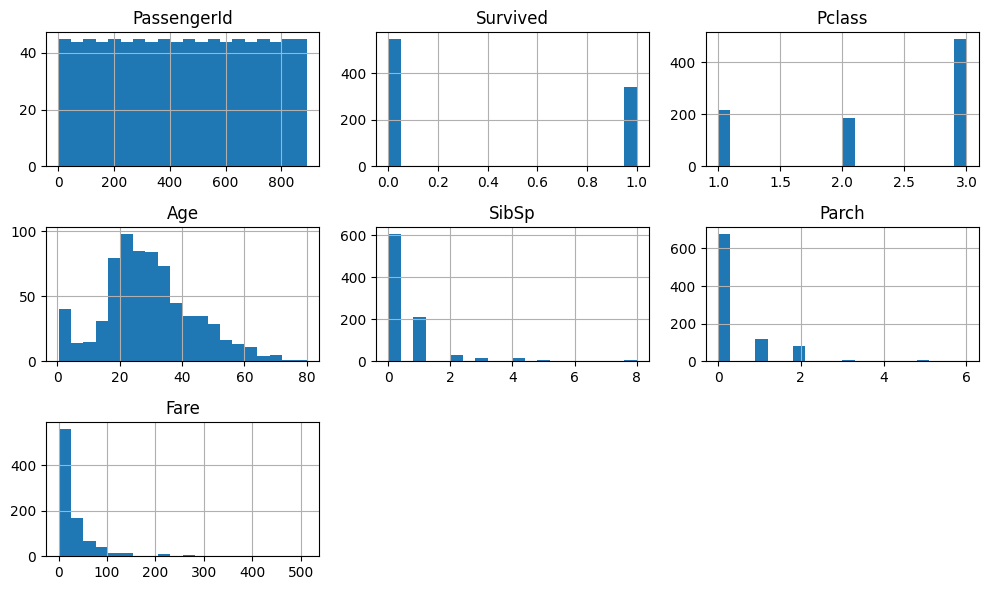

In [9]:
# vizualizar variables numericas
data.hist(figsize=(10, 6), bins=20)
plt.tight_layout()
plt.show()

In [10]:
# lista de varibles categoricas a filtrar
cat_cols = data.select_dtypes(include='object').columns
cat_cols

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

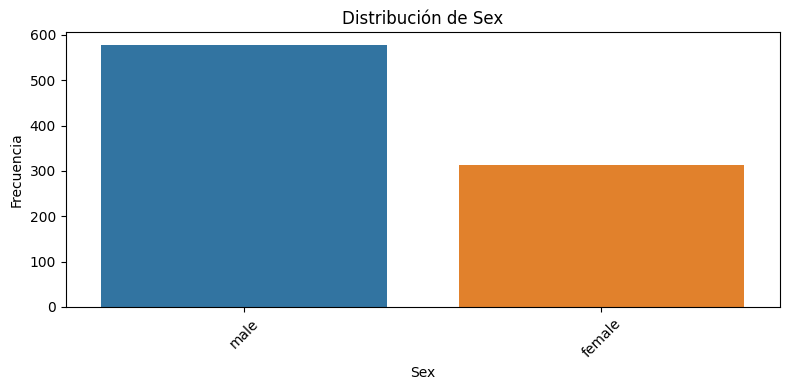

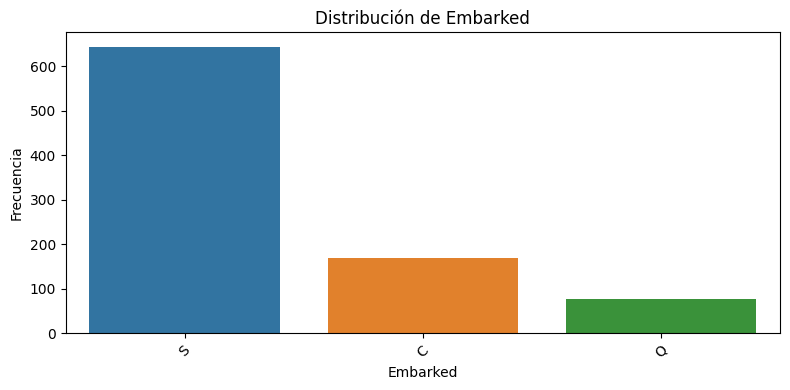

In [11]:
# lista a filtrar
categorical_columns = ['Sex', 'Embarked']

# Iterar sobre las columnas específicas
for column in categorical_columns:
    # Verificar si la columna existe en el DataFrame
    if column in data.columns:
        # Crear un gráfico de barras para la columna actual
        plt.figure(figsize=(8, 4))  # Ajustar tamaño del gráfico
        sns.countplot(data=data, x=column, order=data[column].value_counts().index)
        plt.xticks(rotation=45)  # Rotar etiquetas del eje X si es necesario
        plt.title(f'Distribución de {column}')  # Título del gráfico
        plt.xlabel(column)  # Etiqueta del eje X
        plt.ylabel('Frecuencia')  # Etiqueta del eje Y
        plt.tight_layout()  # Ajustar diseño para evitar recortes
        plt.show()
    else:
        print(f"La columna '{column}' no existe en el DataFrame.")

In [12]:
# filtrar columnas numericas
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
numeric_cols

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

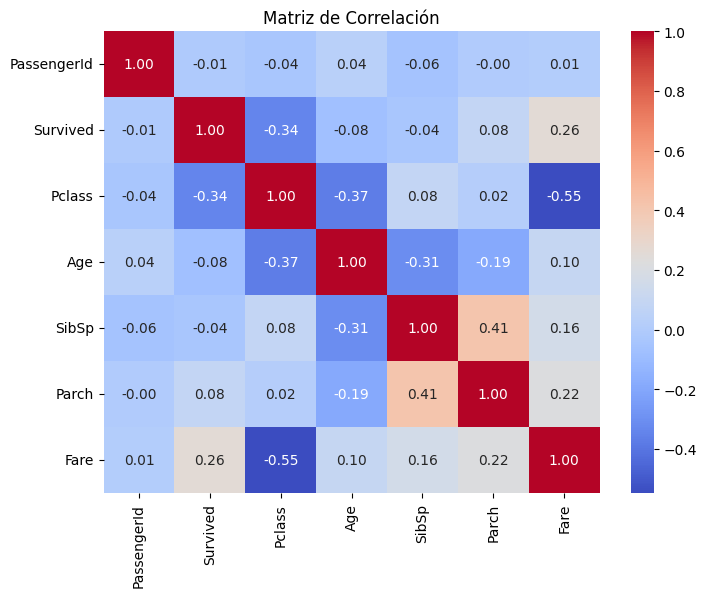

In [13]:
# Filtrar solo las columnas numéricas
numeric_data = data.select_dtypes(include='number')
# Verificar si hay columnas numéricas
if numeric_data.empty:
    print("No hay columnas numéricas en el DataFrame.")
else:
    # Calcular la matriz de correlación
    corr_matrix = numeric_data.corr()

    # Visualizar la matriz de correlación
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Matriz de Correlación')
    plt.show()

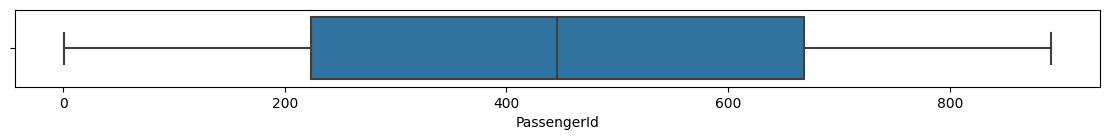

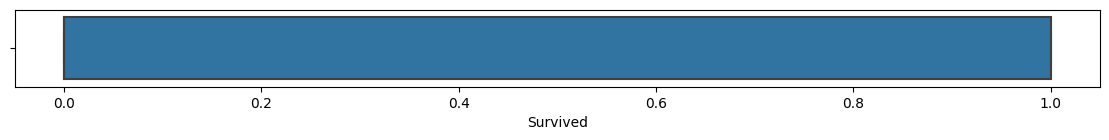

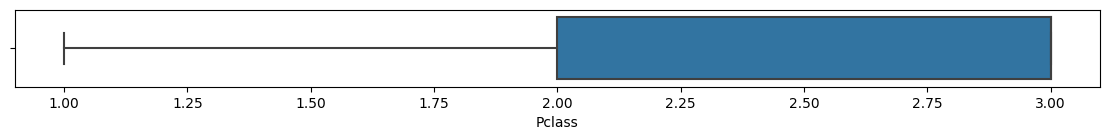

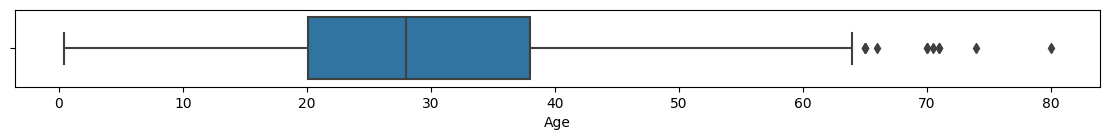

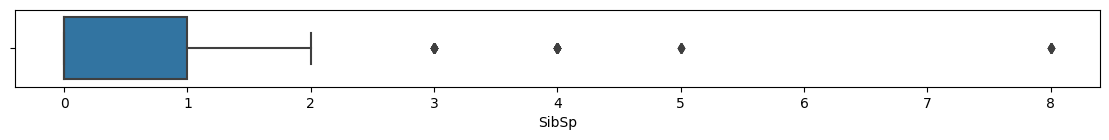

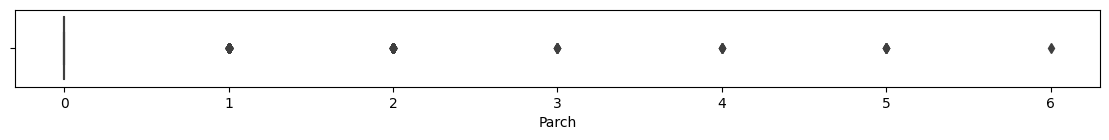

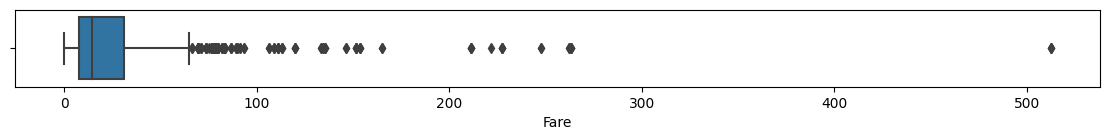

In [14]:
# valores atipicos
num_cols=data.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure(figsize=(14,1))
    sns.boxplot(data=data[num_cols], x=col)  
    plt.show()

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [16]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
# de la columna Pclass cambiar tipo de dato
data['Pclass'] = data['Pclass'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    object  
dtypes: category(1), float64(2), int64(4), object(5)
memory usage: 77.7+ KB


In [18]:
# de la columna Pclass cambiar tipo de dato a numerico
data['Pclass'] = data['Pclass'].astype('int64')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
# Número de outliers usando rango IQR
outliers = {}
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[col] = ((data[col] > upper_bound) | (data[col] < lower_bound)).sum()

# Imprimir el resultado final
print(outliers)

{'PassengerId': 0, 'Survived': 0, 'Pclass': 0, 'Age': 11, 'SibSp': 46, 'Parch': 213, 'Fare': 116}


<Axes: xlabel='Fare', ylabel='Count'>

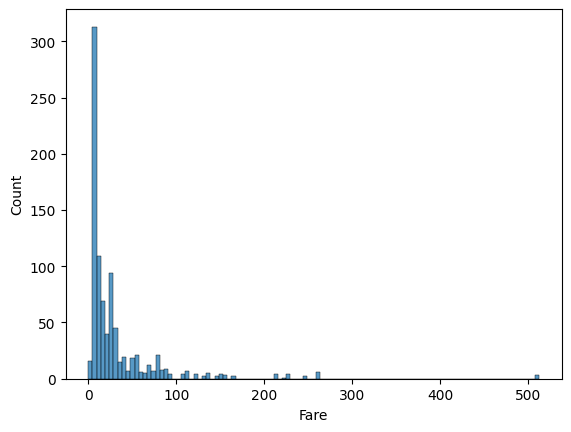

In [20]:
# histograma de  la columna Fare
sns.histplot(data['Fare'])

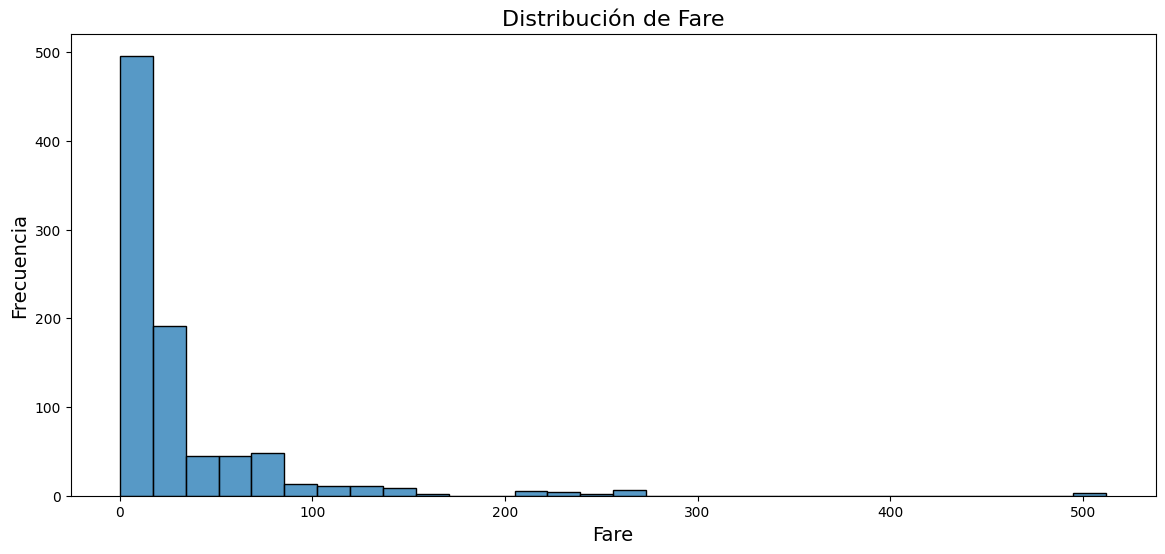

In [21]:
# Definir el tamaño del gráfico
plt.figure(figsize=(14, 6))  # Ancho: 10 pulgadas, Alto: 6 pulgadas

# Crear el histograma
sns.histplot(data['Fare'], kde=False, bins=30)  #espacio enter columnas ajuste `bins` según sea necesario

# Añadir título y etiquetas
plt.title('Distribución de Fare', fontsize=16)
plt.xlabel('Fare', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)

# Mostrar el gráfico
plt.show()

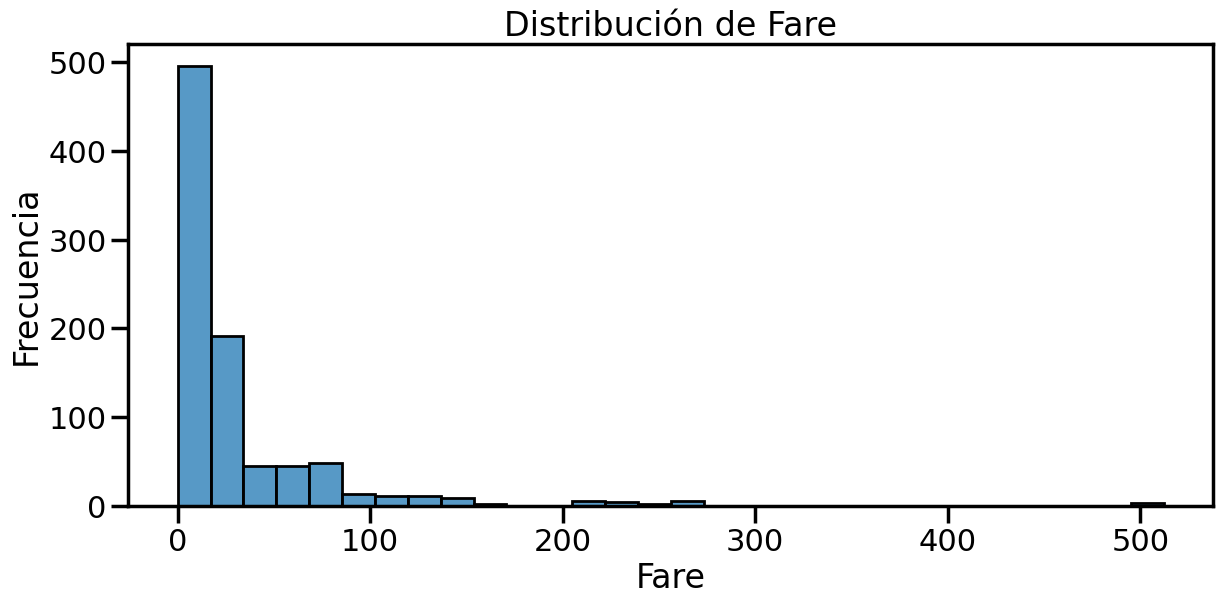

In [22]:
# Ajustar el contexto global de seaborn
sns.set_context("poster")  # Opciones: "paper", "notebook", "talk", "poster"

# Crear el histograma
plt.figure(figsize=(14, 6))
sns.histplot(data['Fare'], kde=False, bins=30)

# Añadir título y etiquetas
plt.title('Distribución de Fare')
plt.xlabel('Fare')
plt.ylabel('Frecuencia')

# Mostrar el gráfico
plt.show()

In [22]:
# suma valores nulos
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [23]:
# porcentaje de valores nulos
(data.isnull().sum() / len(data)) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [24]:
# eliminar valores nulos de la columna Cabin
len(data.Cabin.dropna())

204

In [25]:
# Contar valores no nulos en todas las columnas
data.notna().sum()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

In [26]:
# suma valores nulos
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [27]:
# Contar valores no nulos de forma eficiente
data['Cabin'].count()

204

In [28]:
# eliminar columna Cabin del dataframe de manera permanente
data.drop('Cabin', axis=1, inplace=True)
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [30]:
import plotly.express as px

# Crear el histograma con Plotly
fig = px.histogram(data, x='Age', nbins=30, title='Distribución de Age',
                   labels={'Age': 'Edad', 'count': 'Frecuencia'},
                   color_discrete_sequence=['skyblue'])

# Personalizar el diseño
fig.update_layout(
    title_font_size=24,
    xaxis_title_font_size=18,
    yaxis_title_font_size=18,
    template='plotly_white'
)

# Guardar como archivo HTML
fig.write_html('fare_distribution.html')

# Mostrar el gráfico
fig.show()

In [31]:
# Crear el histograma interactivo con Plotly Express
fig = px.histogram(data, x='Age', nbins=30, title='Distribución de Edades',
                   labels={'Age': 'Edad', 'count': 'Frecuencia'},  # Etiquetas personalizadas
                   color_discrete_sequence=['#636EFA'],  # Color de las barras
                   marginal="box")  # Agregar un boxplot encima para resaltar la distribución

# Personalizar el diseño del gráfico
fig.update_layout(
    title_font_size=24,  # Tamaño del título
    xaxis_title_font_size=18,  # Tamaño de la etiqueta del eje X
    yaxis_title_font_size=18,  # Tamaño de la etiqueta del eje Y
    template='plotly_white',  # Estilo de fondo blanco limpio
    bargap=0.1  # Espaciado entre las barras
)

# Mostrar el gráfico
fig.show()

# Guardar el gráfico como archivo HTML (opcional)
fig.write_html('histogram_age.html')

In [32]:
# imputar la columna Age con la mediana
impute= SimpleImputer(strategy='median')

print('Mediana inicial:', data['Age'].median())

salida = impute.fit_transform(data[['Age']])

salida = pd.DataFrame(salida)

print('\nNulos en los nuevos datos:', salida.isna().sum())
print('\nMediana en los nuevos datos:', salida.median())

Mediana inicial: 28.0

Nulos en los nuevos datos: 0    0
dtype: int64

Mediana en los nuevos datos: 0    28.0
dtype: float64


In [33]:
data.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [34]:
# rellenar valores en la columna Embarked con la constante 'S'
impute = SimpleImputer(strategy='constant', fill_value='S')

print('Recuento Inicial:', data['Embarked'].value_counts())

salida = impute.fit_transform(data[['Embarked']])
salida = pd.DataFrame(salida)
print('\nNulos en los nuevos datos:', salida.isna().sum())
print('\nRecuento en los nuevos datos:', salida.value_counts())

Recuento Inicial: Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Nulos en los nuevos datos: 0    0
dtype: int64

Recuento en los nuevos datos: S    646
C    168
Q     77
Name: count, dtype: int64
